# Chunk Steering: Load KL Curves, Plot, and Fit
This notebook loads precomputed KL(beta) curves saved by `scripts/collect_kl_curves.py` and produces combined KL vs beta plots and amplitude-vs-metric scatterplots. It also fits an inverse model a/x + b and compares it to independent exponentials using AIC/BIC, Vuong test, and 5-fold CV.

In [1]:
import os, json, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Configure which steer file to load
model_name = 'deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B'
steer_type = 'centered'  # options: 'per-chunk' | 'centered' | 'diff-in-means'
model_tag = model_name.replace('/', '-')
repo_root = Path.cwd().resolve().parents[0] if (Path.cwd()).exists() else Path.cwd().resolve()
annotated_path = repo_root / 'data' / f'annotated_data_{model_tag}.json'
kl_path = repo_root / 'data' / f'kl_curves_steer_{steer_type}_{model_tag}.json'
print('Loading:', kl_path)
with open(annotated_path,'r') as f: annotated = json.load(f)
with open(kl_path,'r') as f: payload = json.load(f)
examples = [ex for ex in annotated if ex.get('thought_anchor_sentence')]
curves = payload.get('curves', [])
betas = np.asarray(payload.get('betas', []), dtype=float)
len(examples), len(curves), betas[:5] if betas.size > 0 else betas

Loading: /home/cutterdawes/SteeringThoughtAnchors/data/kl_curves_steer_centered_deepseek-ai-DeepSeek-R1-Distill-Qwen-1.5B.json


(20, 533, array([-10.,  -9.,  -8.,  -7.,  -6.]))

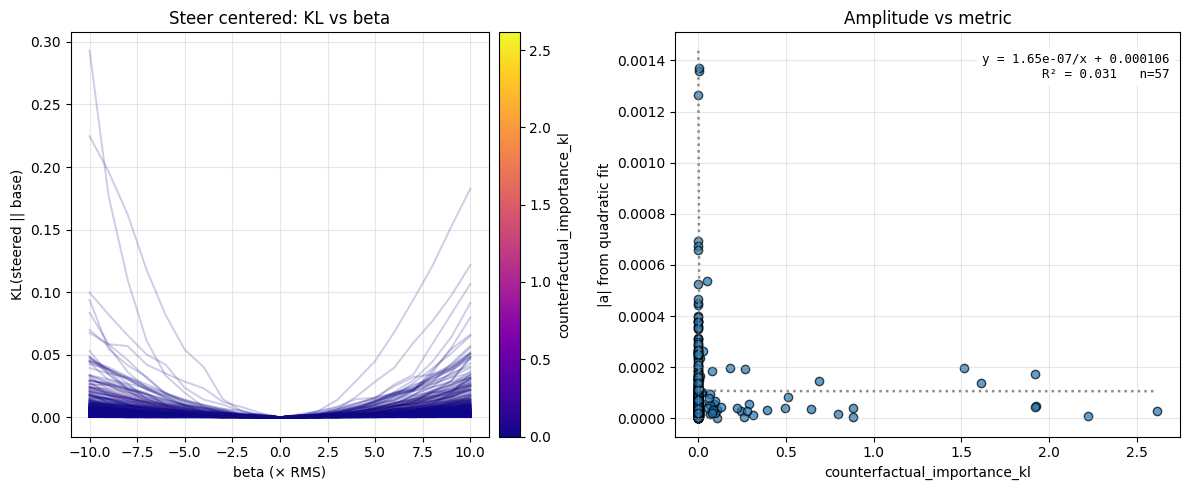

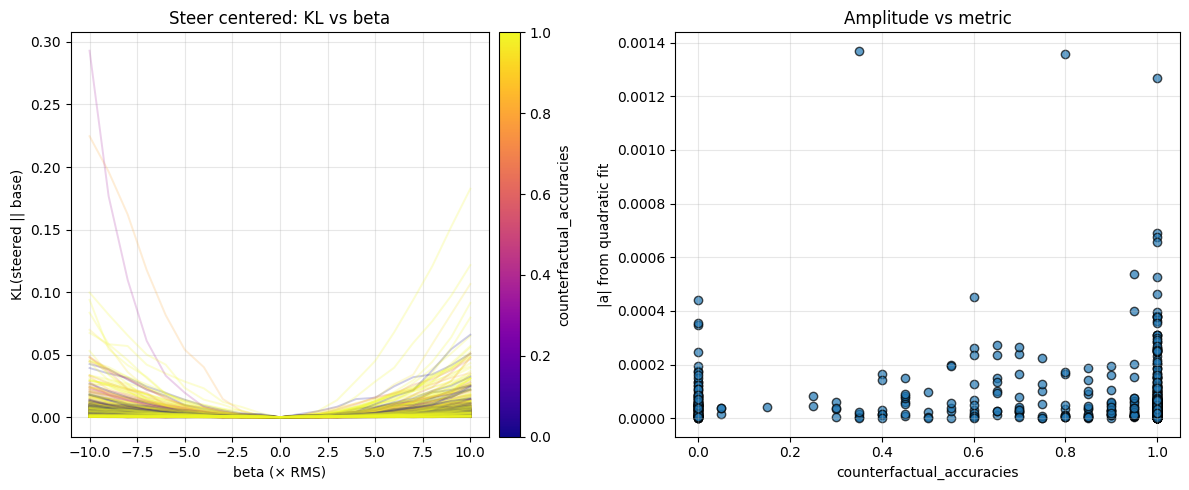

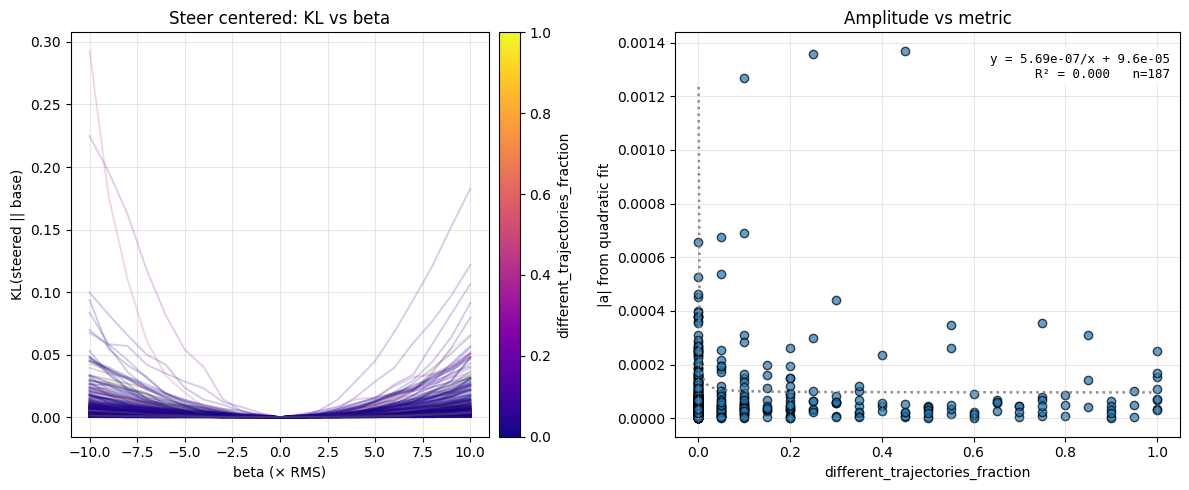

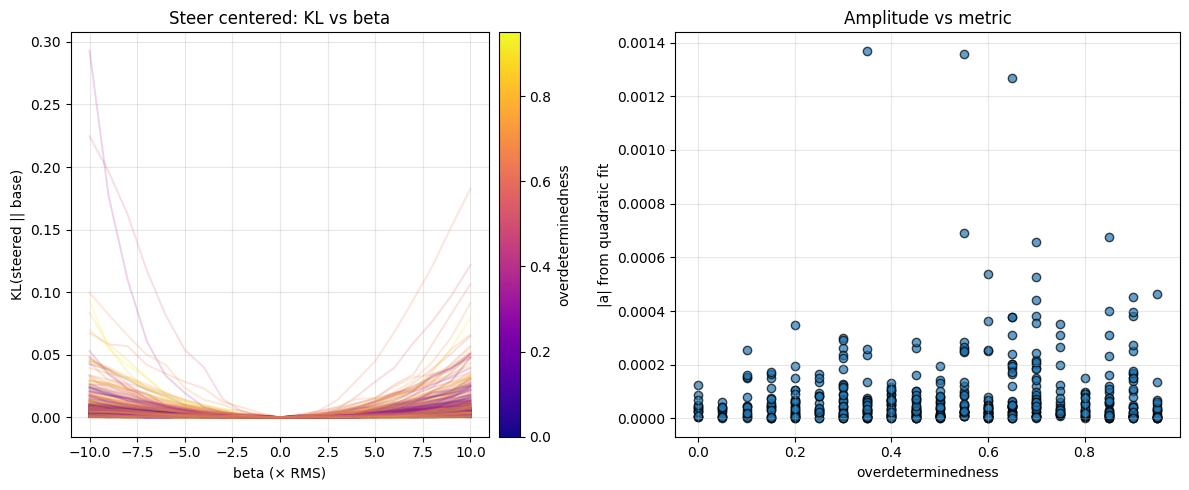

In [4]:
# Plot combined figures (KL vs beta and amplitude vs metric)
import numpy as np
from matplotlib.colors import Normalize

repo_root = Path.cwd().resolve().parents[0] if (Path.cwd()).exists() else Path.cwd().resolve()
import sys
sys.path.append(str(repo_root))

from utils import normalize_by_group

metric_key_to_label = {
    'kl': 'counterfactual_importance_kl',
    'acc': 'counterfactual_accuracies',
    'diff': 'different_trajectories_fraction',
    'over': 'overdeterminedness',
}

def _get_metric_from_example(ex, idx: int, metric_key: str) -> float:
    arr = ex.get(metric_key_to_label[metric_key], []) or []
    try: return float(arr[idx]) if idx < len(arr) else 0.0
    except Exception: return 0.0

def _fit_amp_quadratic(xs: np.ndarray, ys: np.ndarray) -> float:
    n = min(xs.size, ys.size)
    if n < 3: return np.nan
    try: return abs(float(np.polyfit(xs[:n], ys[:n], 2)[0]))
    except Exception: return np.nan

def plot_combined_for_chunk_list(curves: list, examples_list: list, x_values: np.ndarray, metric_key: str, title_prefix: str, save_tag: str = None, normalize_amp: bool = True):
    vals, amps, ex_keys = [], [], []
    for c in curves:
        ex_i = int(c.get('example_index', 0)); ch_i = int(c.get('chunk_index', 0))
        vals.append(_get_metric_from_example(examples_list[ex_i], ch_i, metric_key))
        ex_keys.append(ex_i)
        ys = np.asarray(c.get('ys', []) or [], dtype=float)
        amps.append(_fit_amp_quadratic(np.asarray(x_values, dtype=float), ys))
    M = np.asarray(vals, dtype=float); A = np.asarray(amps, dtype=float)
    A_plot = np.asarray(normalize_by_group(ex_keys, A), dtype=float) if normalize_amp else A
    vmin, vmax = (0.0, (np.nanmax(M) if np.isfinite(np.nanmax(M)) else 1.0)) if metric_key != 'kl' else (0.0, (np.nanmax(M) if np.isfinite(np.nanmax(M)) else 0.01))
    norm = Normalize(vmin=vmin, vmax=max(vmin+1e-9, vmax)); cmap = plt.cm.plasma
    fig, axes = plt.subplots(1,2, figsize=(12,5)); ax0, ax1 = axes
    for c, m in zip(curves, M):
        ys = np.asarray(c.get('ys', []) or [], dtype=float)
        n = min(len(x_values), len(ys))
        if n == 0: continue
        ax0.plot(x_values[:n], ys[:n], color=cmap(norm(m)), linewidth=1.4, alpha=0.2)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array(M)
    cb = fig.colorbar(sm, ax=ax0, pad=0.02); cb.set_label(metric_key_to_label[metric_key])
    ax0.set_xlabel('beta (× RMS)'); ax0.set_ylabel('KL(steered || base)'); ax0.set_title(f'{title_prefix}: KL vs beta')
    ax0.grid(True, alpha=0.3)
    ax1.scatter(M, A_plot, edgecolor='black', alpha=0.7)
    ax1.set_xlabel(metric_key_to_label[metric_key]); ax1.set_ylabel(('normalized |a| (per example)' if normalize_amp else '|a| from quadratic fit'))
    ax1.set_title('Amplitude vs metric'); ax1.grid(True, alpha=0.3)

    # Optional inverse fit overlay (y = a/x + b) for selected metrics
    if metric_key in ('kl', 'diff'):
        xm = np.asarray(M, dtype=float)
        ym = np.asarray(A_plot, dtype=float)
        mask = np.isfinite(xm) & np.isfinite(ym) & (xm > 1e-12)
        if mask.sum() >= 3:
            X = np.vstack([1.0/xm[mask], np.ones(mask.sum())]).T
            coef, *_ = np.linalg.lstsq(X, ym[mask], rcond=None)
            a, b = float(coef[0]), float(coef[1])
            # R^2 on masked points
            yhat = a*(1.0/xm[mask]) + b
            ss_res = np.sum((ym[mask] - yhat)**2)
            ss_tot = np.sum((ym[mask] - np.mean(ym[mask]))**2)
            r2 = 1.0 - (ss_res/ss_tot if ss_tot > 1e-12 else 0.0)

            # Prepare an x-grid that extends toward zero (but avoids exact zero) so the inverse curve
            # visually reaches the upper y-limit near x->0. Clip plotted y to the current axis top
            xmin_data = float(xm[mask].min())
            xmax_data = float(xm[mask].max())
            eps = max(xmin_data * 0.01, 1e-12)
            xs = np.linspace(eps, xmax_data, 400)

            # get current y-limits before plotting the curve so we can clip to the top
            ymin, ymax = ax1.get_ylim()
            ys_fit = a * (1.0 / xs) + b
            # Clip so the curve reaches the top y-limit instead of expanding the axis to huge values
            ys_plot = np.minimum(ys_fit, ymax)

            # Plot the inverse fit as a dotted grey curve that extends toward x->0
            ax1.plot(xs, ys_plot, color='gray', linestyle='dotted', linewidth=1.8, alpha=0.9, zorder=3)

            # Combine fit info and R^2 into a tidy textbox in the top-right
            fit_text = (
                f"y = {a:.3g}/x + {b:.3g}\n"
                f"R\u00b2 = {r2:.3f}   n={int(mask.sum())}"
            )
            ax1.text(0.98, 0.95, fit_text, transform=ax1.transAxes,
                     ha='right', va='top', fontsize=9, family='monospace',
                     bbox=dict(facecolor='white', alpha=0.9, edgecolor='none'))
    plt.tight_layout(); plt.show()

metrics = ['kl','acc','diff','over']
for mk in metrics:
    plot_combined_for_chunk_list(curves, examples, betas, mk, f'Steer {steer_type}', save_tag=None, normalize_amp=False)

In [15]:
# Fit scatter: inverse a/x+b vs independent exponentials
import numpy as np
from dataclasses import dataclass
from scipy.optimize import minimize

def _MA_from_curves(curves, examples, x_values, metric_key):
    vals = []; amps = []
    for c in curves:
        ex_i = int(c.get('example_index', 0)); ch_i = int(c.get('chunk_index', 0))
        arr = examples[ex_i].get({'kl':'counterfactual_importance_kl','acc':'counterfactual_accuracies','diff':'different_trajectories_fraction','over':'overdeterminedness'}[metric_key], []) or []
        v = float(arr[ch_i]) if ch_i < len(arr) else 0.0
        ys = np.asarray(c.get('ys', []), dtype=float)
        n = min(len(x_values), len(ys))
        if n < 3: continue
        acoef = float(np.polyfit(x_values[:n], ys[:n], 2)[0])
        vals.append(v); amps.append(abs(acoef))
    X = np.asarray(vals, dtype=float); Y = np.asarray(amps, dtype=float)
    X = np.clip(X, 0, None); Y = np.clip(Y, 0, None)
    m = np.isfinite(X) & np.isfinite(Y)
    return X[m], Y[m]

def fit_m1(x, y):
    lam_x = 1.0 / np.mean(x); lam_y = 1.0 / np.mean(y); return lam_x, lam_y
def ll_m1_pointwise(x, y, lam_x, lam_y):
    return (np.log(lam_x) - lam_x*x) + (np.log(lam_y) - lam_y*y)
def _sse_ab(theta, x, y):
    a, b = theta; pred = a + b / x; return np.sum((y - pred)**2)
def fit_m2(x, y):
    eps = 1e-12; x = np.clip(x, eps, None); X = np.vstack([np.ones_like(x), 1.0/x]).T
    a0, b0 = np.linalg.lstsq(X, y, rcond=None)[0]
    res = minimize(lambda th: _sse_ab(th, x, y), x0=np.array([a0, b0]), method='BFGS')
    a, b = res.x; resid = y - (a + b/x); sigma2 = np.mean(resid**2); return a, b, float(np.sqrt(sigma2))
def ll_m2_pointwise(x, y, a, b, sigma):
    eps = 1e-12; x = np.clip(x, eps, None); resid = y - (a + b/x); return -0.5*np.log(2*np.pi*sigma**2) - 0.5*(resid**2)/(sigma**2)
@dataclass
class FitScores: n: int; ll: float; ll_avg: float; aic: float; bic: float
def scores_from_ll(ll_pointwise, k_params):
    ll = float(np.sum(ll_pointwise)); n = len(ll_pointwise); return FitScores(n=n, ll=ll, ll_avg=ll/n, aic=2*k_params - 2*ll, bic=k_params*np.log(n) - 2*ll)
def vuong_test(ll2_pointwise, ll1_pointwise):
    r = ll2_pointwise - ll1_pointwise; n = len(r); rbar = np.mean(r); sr = np.std(r, ddof=1); Z = np.sqrt(n) * rbar / sr; return Z, rbar, sr
def kfold_logscore(x, y, K=5, seed=0):
    rng = np.random.default_rng(seed); n = len(x); idx = np.arange(n); rng.shuffle(idx); folds = np.array_split(idx, K)
    ll1_total = 0.0; ll2_total = 0.0; n_total = 0
    for k in range(K):
        test_idx = folds[k]; train_idx = np.setdiff1d(idx, test_idx, assume_unique=False)
        lam_x, lam_y = fit_m1(x[train_idx], y[train_idx]); a, b, s = fit_m2(x[train_idx], y[train_idx])
        ll1 = ll_m1_pointwise(x[test_idx], y[test_idx], lam_x, lam_y).sum(); ll2 = ll_m2_pointwise(x[test_idx], y[test_idx], a, b, s).sum()
        ll1_total += ll1; ll2_total += ll2; n_total += len(test_idx)
    return (ll1_total, ll1_total/n_total), (ll2_total, ll2_total/n_total)

metrics = ['kl','acc','diff','over']
for mk in metrics:
    x, y = _MA_from_curves(curves, examples, betas, mk)
    if len(x) < 8:
        print('[steer %s] %s: not enough points' % (steer_type, mk)); continue
    lam_x, lam_y = fit_m1(x, y); ll1_pw = ll_m1_pointwise(x, y, lam_x, lam_y); s1 = scores_from_ll(ll1_pw, k_params=2)
    a, b, sigma = fit_m2(x, y); ll2_pw = ll_m2_pointwise(x, y, a, b, sigma); s2 = scores_from_ll(ll2_pw, k_params=3)
    Z, rbar, sr = vuong_test(ll2_pw, ll1_pw); (ll1_cv, ll1_cv_avg), (ll2_cv, ll2_cv_avg) = kfold_logscore(x, y, K=5)
    print('[steer %s] %s: M1 ll_avg=%.4f AIC=%.1f | M2 ll_avg=%.4f AIC=%.1f Vuong Z=%.2f CV M1=%.4f M2=%.4f' % (steer_type, mk, s1.ll_avg, s1.aic, s2.ll_avg, s2.aic, Z, ll1_cv_avg, ll2_cv_avg))

[steer centered] kl: M1 ll_avg=10.6010 AIC=-11296.6 | M2 ll_avg=7.4855 AIC=-7973.5 Vuong Z=-11.83 CV M1=10.5671 M2=7.4379
[steer centered] acc: M1 ll_avg=7.7219 AIC=-8227.5 | M2 ll_avg=7.4804 AIC=-7968.1 Vuong Z=-2.59 CV M1=7.7181 M2=7.4369
[steer centered] diff: M1 ll_avg=9.5871 AIC=-10215.8 | M2 ll_avg=7.4857 AIC=-7973.8 Vuong Z=-17.19 CV M1=9.5764 M2=7.4415
[steer centered] over: M1 ll_avg=8.1002 AIC=-8630.8 | M2 ll_avg=7.4805 AIC=-7968.3 Vuong Z=-6.60 CV M1=8.0966 M2=7.4373
